In [1]:
#As always, we start by importing the things we will need

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry, EllipticalAperture, EllipticalAnnulus
from astropy.nddata import Cutout2D
from matplotlib.patches import Ellipse

#Might need to pip install photutils

In [ ]:
#Here is the general flow of today's notebook

#Make a cutout of the dwarf galaxy we will study for the rest of the project
#Draw aperture for calculating magnitudes and radii
#Display aperture and make sure it makes sense
#Draw annulus for background subtraction
#Display annulus and make sure it looks right
#Calculate the magnitude of the dwarf galaxy!

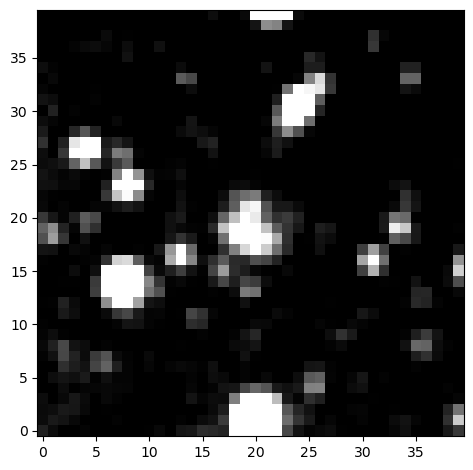

In [7]:
# 1. Load image and make a cutout
hdu = fits.open('Kamino_dwarf.fits')[0]#FILL IN WITH FILEPATH!
data = hdu.data
header=hdu.header

cmap=plt.cm.Greys_r

#Since we should already have ds9 open, use that to make an estinate of position and size!

position=(890, 1601)#FILL IN
size=(40, 40)#FILL IN
cutout=Cutout2D(data, position, size)

minim=np.percentile(cutout.data, 60)
maxim=np.percentile(cutout.data, 96)


plt.imshow(cutout.data, origin='lower', cmap=cmap, vmin=minim, vmax=maxim, norm='log')
plt.tight_layout()

plt.show()


In [14]:
# 2. Now we need to draw a shape around the galaxy to calculate the signal inside

position = (19.5, 19)#FILL IN
a, b, theta = 9.5, 6.2, np.radians(-45)#FILL IN
aperture = EllipticalAperture(position, a, b, theta)

aper_overlay=Ellipse(
    xy=position,
    width=a,
    height=b,
    angle=np.degrees(theta),
    edgecolor='red',   # Outline color
    facecolor='none', # Fill color (use 'none' for a transparent fill)
    linewidth=2,       # Thickness of the outline
    alpha=1.0          # Transparency
)

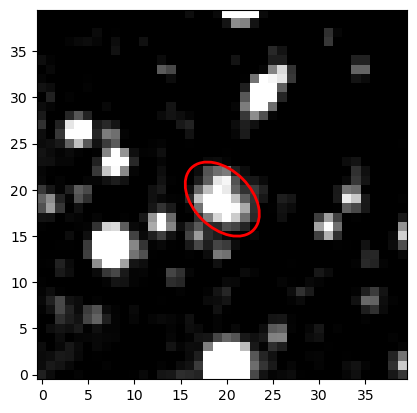

In [15]:
# 3. Here we are checking to make sure the shape we drew does a good job of covering the galaxy
fig, ax = plt.subplots()
ax.imshow(cutout.data, origin='lower', cmap=cmap, vmin=minim, vmax=maxim, norm='log')
ax.add_patch(aper_overlay)
plt.show()

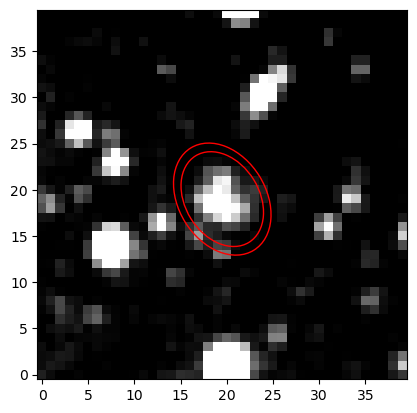

In [25]:
# 4. Now that we're happy with our aperture, we need to make our annulus
#The annulus is like the aperture, but instead of calculating the signal of the galaxy
#we are detecting how strong the background is, so we can subtract it out later
a_in=11
a_out=13
b_in=8
b_out=b_in*(a_out/a_in)
theta = -45

annulus = EllipticalAnnulus(position, a_in, a_out, b_out, b_in, theta)

ann_overlay_in=Ellipse(
    xy=position,
    width=a_in,
    height=b_in,
    angle=np.degrees(theta),
    edgecolor='red',   # Outline color
    facecolor='none', # Fill color (use 'none' for a transparent fill)
    linewidth=1,       # Thickness of the outline
    alpha=1.0          # Transparency
)

ann_overlay_out=Ellipse(
    xy=position,
    width=a_out,
    height=b_out,
    angle=np.degrees(theta),
    edgecolor='red',   # Outline color
    facecolor='none', # Fill color (use 'none' for a transparent fill)
    linewidth=1,       # Thickness of the outline
    alpha=1.0          # Transparency
)


#Let's see how this shape looks. We want to avoid stars and mostly just get blank sky
fig, ax = plt.subplots()
ax.imshow(cutout.data, origin='lower', cmap=cmap, vmin=minim, vmax=maxim, norm='log')
#ADD THE INNER AND OUTER ANNULUS
ax.add_patch(ann_overlay_in)
ax.add_patch(ann_overlay_out)
plt.show()

In [27]:
zeroPoint = header['ZEROPT']

22.33857797452318


In [28]:
# 5. Now we can actually calculate how bright the galaxy is!
# The aperture_photometry command sums the pixel signal inside our aperture and annulus
# we need to define what the zeropoint is for calibration purposes! Use the header for this

zp= header['ZEROPT']

phot_table = aperture_photometry(cutout.data, [aperture, annulus])

bkg_mean = phot_table['aperture_sum_1'] / annulus.area
net_flux = phot_table['aperture_sum_0'] - (bkg_mean * aperture.area)
magnitude = (-2.5 * np.log10(net_flux)) + zp

print(f"Magnitude: {magnitude[0]}")

Magnitude: 17.418985214569332


In [ ]:
#Evan's numbers in case things go terribly wrong

#For cutout
hdu = fits.open('/Users/evanjennerjahn/Library/CloudStorage/OneDrive-TheOhioStateUniversity/Polaris 2026 Project/Ithea/WLM_dwarf.fits')[0]
position=(895, 362)
size=(140,140)

#For aperture
position = (70, 70)
a, b, theta = 88, 32, np.radians(90)

#For Annulus
a_in=90
a_out=100
b_in=40
b_out=b_in*(a_out/a_in)


zp=header['ZEROPT']
